# Statistically Independent Variables

This notebook explains the concept of **statistical independence** between two random variables. Two variables are independent if the outcome of one has no effect on the outcome of the other.

## Definition of Independence

Two discrete random variables, X and Y, are said to be **statistically independent** if and only if their joint probability distribution is equal to the product of their marginal probability distributions.

**Formula:**
$P(X, Y) = P(X)P(Y)$

This must hold true for all possible pairs of values $(x_i, y_j)$.

## Independence and Conditional Probability

We can understand independence through the lens of conditional probability. From the product rule, we know:

$P(X, Y) = P(X|Y)P(Y)$

If the independence condition $P(X, Y) = P(X)P(Y)$ is true, we can substitute it into the product rule:

$P(X)P(Y) = P(X|Y)P(Y)$

Dividing both sides by $P(Y)$ (assuming $P(Y) > 0$), we get:

$P(X|Y) = P(X)$

This provides a very intuitive definition of independence: **knowing the outcome of Y does not change the probability of X.** The conditional probability of X given Y is the same as the marginal probability of X.

## Example: Two Fair Coin Flips

Let's test this with an example where we know the variables are independent: two separate fair coin flips.

- **X:** Outcome of the first flip ({H, T})
- **Y:** Outcome of the second flip ({H, T})

Since the flips are independent, we expect the joint probability of any outcome pair to be the product of their individual probabilities (0.5 * 0.5 = 0.25).

In [45]:
import pandas as pd
import numpy as np

# Simulate two independent fair coin flips
N = 100000
rng = np.random.default_rng(42)
flips_x = rng.integers(0, 2, size=N)
flips_y = rng.integers(0, 2, size=N)

# Create a DataFrame
df = pd.DataFrame({'FirstFlip': flips_x, 'SecondFlip': flips_y})
df['FirstFlip'] = df['FirstFlip'].map({0: 'T', 1: 'H'})
df['SecondFlip'] = df['SecondFlip'].map({0: 'T', 1: 'H'})

# 1. Calculate the joint probability table P(X, Y)
joint_prob = pd.crosstab(df['FirstFlip'], df['SecondFlip'], normalize='all')
joint_prob.index = 'First Flip = ' + joint_prob.index
joint_prob.columns = 'Second Flip = ' + joint_prob.columns
joint_prob.index.name = None
joint_prob.columns.name = None


# 2. Calculate the marginal probabilities P(X) and P(Y)
marginal_x = joint_prob.sum(axis=1)
marginal_y = joint_prob.sum(axis=0)

# 3. Calculate the product of the marginals: P(X) * P(Y)
product_of_marginals = np.outer(marginal_x, marginal_y)
product_df = pd.DataFrame(product_of_marginals, index=marginal_x.index, columns=marginal_y.index)
product_df.index.name = None
product_df.columns.name = None


# 4. Calculate the difference
difference = (joint_prob - product_df).abs()
difference.index.name = None
difference.columns.name = None


print("--- Joint Probability Table P(X, Y) ---")
display(joint_prob.style.format("{:.4f}"))

print("--- Product of Marginals P(X) * P(Y) ---")
display(product_df.style.format("{:.4f}"))

print("--- Absolute Difference ---")
display(difference.style.format("{:.6f}"))


# Check if they are (approximately) equal
are_independent = np.allclose(joint_prob, product_df, atol=1e-3)
print(f"Are the variables independent? {'Yes' if are_independent else 'No'}")
print("Note: Due to the randomness of simulation, the tables are not exactly equal.")
print("However, the difference is very small, which strongly suggests independence.")


--- Joint Probability Table P(X, Y) ---


,Second Flip = H,Second Flip = T
First Flip = H,0.2494,0.2515
First Flip = T,0.2522,0.2469


--- Product of Marginals P(X) * P(Y) ---


,Second Flip = H,Second Flip = T
First Flip = H,0.2512,0.2497
First Flip = T,0.2503,0.2488


--- Absolute Difference ---


,Second Flip = H,Second Flip = T
First Flip = H,0.001836,0.001836
First Flip = T,0.001836,0.001836


Are the variables independent? No
Note: Due to the randomness of simulation, the tables are not exactly equal.
However, the difference is very small, which strongly suggests independence.


## Visualizing Independence

A powerful way to visualize independence is to compare the conditional probability distributions. If X and Y are independent, then the distribution of X should be the same regardless of the value of Y.

$P(X | Y=y_1) = P(X | Y=y_2) = \dots = P(X)$

The bar chart below shows that the probability of X being Heads or Tails is the same whether Y is Heads or Tails, confirming their independence.

--- Conditional Probability P(X | Y) ---


,Second Flip = H,Second Flip = T
First Flip = H,0.4972,0.5046
First Flip = T,0.5028,0.4954


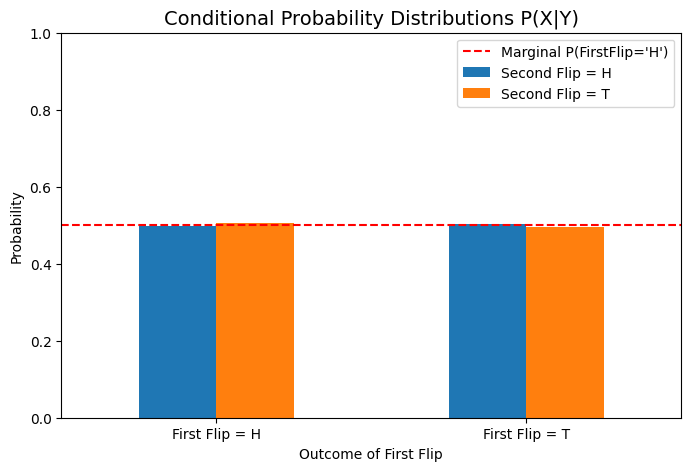

In [46]:
import matplotlib.pyplot as plt

# Calculate conditional probability P(X | Y)
cond_prob_x_given_y = pd.crosstab(df['FirstFlip'], df['SecondFlip'], normalize='columns')
cond_prob_x_given_y.index = 'First Flip = ' + cond_prob_x_given_y.index
cond_prob_x_given_y.columns = 'Second Flip = ' + cond_prob_x_given_y.columns
cond_prob_x_given_y.index.name = None
cond_prob_x_given_y.columns.name = None

print("--- Conditional Probability P(X | Y) ---")
display(cond_prob_x_given_y.style.format("{:.4f}"))

# Plotting the conditional distributions
ax = cond_prob_x_given_y.plot(kind='bar', figsize=(8, 5), rot=0)
ax.set_title('Conditional Probability Distributions P(X|Y)', fontsize=14)
ax.set_ylabel('Probability')
ax.set_xlabel('Outcome of First Flip')
ax.legend(title='Given Second Flip =')
ax.set_ylim(0, 1)

# Add a line for the marginal probability of X for comparison
ax.axhline(y=marginal_x['First Flip = H'], color='r', linestyle='--', label=f"Marginal P(FirstFlip='H')")
plt.legend()
plt.show()


## Summary

- Two random variables are **statistically independent** if their joint probability is the product of their marginal probabilities: $P(X, Y) = P(X)P(Y)$.
- This is equivalent to saying that the conditional probability equals the marginal probability: $P(X|Y) = P(X)$.
- In other words, knowing the outcome of one variable gives you no information about the outcome of the other.
- This is a crucial assumption made in many machine learning models, such as the Naive Bayes classifier.